# Exploratory Data Analysis

In [2]:
import sys
sys.path.insert(0, "..")

import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

from src.data.loader import load_ratings
from src.data.loader import load_movies
from src.data.loader import load_users

In [3]:
seaborn.set_theme(style="whitegrid")
pandas.set_option("display.max_columns", None)

In [4]:
TOP_PERCENT_TIERS = [0.01, 0.05, 0.10, 0.20]
COLD_START_THRESHOLD = 20
PERCENTILES = [10, 25, 50, 75, 90, 95, 99]

## 1. Data Loading

In [5]:
ratings = load_ratings()
movies = load_movies()
users = load_users()

print(f"Ratings: {len(ratings):,}")
print(f"Movies: {len(movies):,}")
print(f"Users: {len(users):,}")

Ratings: 1,000,209
Movies: 3,883
Users: 6,040


In [6]:
ratings.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [7]:
movies.head()

,item_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## 2. Interaction Sparsity Analysis

In [9]:
number_of_users = ratings["user_id"].nunique()
number_of_movies = ratings["item_id"].nunique()
number_of_interactions = len(ratings)
possible_interactions = number_of_users * number_of_movies
sparsity = 1 - (number_of_interactions / possible_interactions)
density = number_of_interactions / possible_interactions

print(f"Number of users: {number_of_users:,}")
print(f"Number of movies: {number_of_movies:,}")
print(f"Number of interactions: {number_of_interactions:,}")
print(f"Possible interactions: {possible_interactions:,}")
print(f"Sparsity: {sparsity:.4%}")
print(f"Density: {density:.4%}")

Number of users: 6,040
Number of movies: 3,706
Number of interactions: 1,000,209
Possible interactions: 22,384,240
Sparsity: 95.5316%
Density: 4.4684%


### Sparsity Interpretation

The user-movie matrix is extremely sparse. This has important modeling implications:

- **Collaborative Filtering**: High sparsity makes it harder to find similar users/movies with overlapping interactions
- **Matrix Factorization**: Needs regularization to prevent overfitting on observed entries
- **Cold Start**: New users/movies have no interactions to leverage

## 3. User Activity Distribution

In [10]:
ratings_per_user = ratings.groupby("user_id").size()

print("Ratings per user statistics:")
print(ratings_per_user.describe())

Ratings per user statistics:
count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64


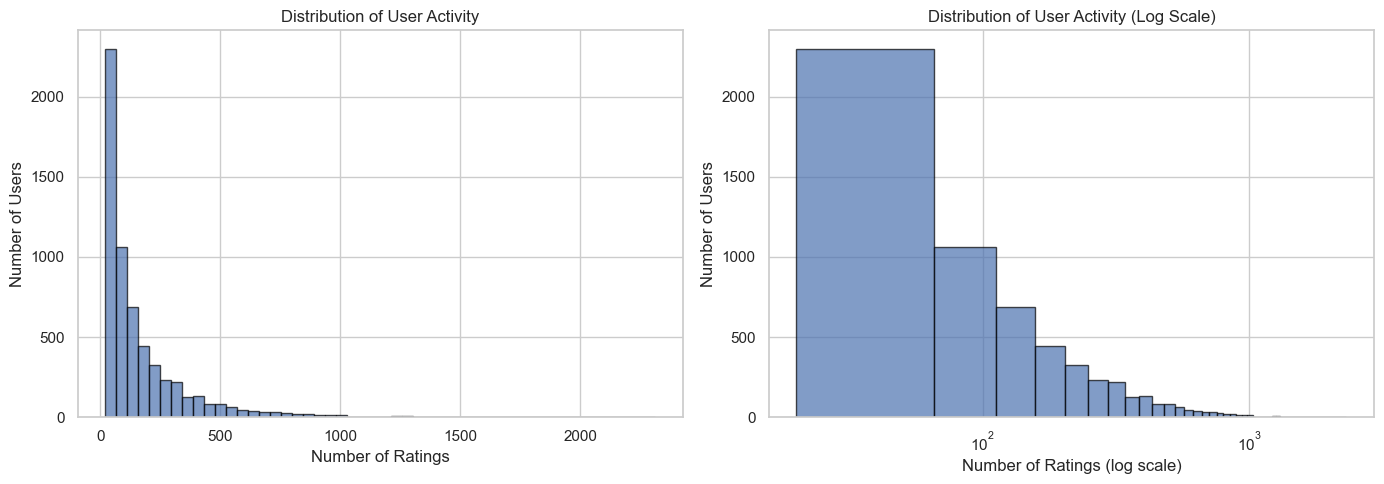

In [11]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes[0].hist(
    ratings_per_user,
    bins=50,
    edgecolor="black",
    alpha=0.7
)
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Distribution of User Activity")

axes[1].hist(
    ratings_per_user,
    bins=50,
    edgecolor="black",
    alpha=0.7
)
axes[1].set_xlabel("Number of Ratings (log scale)")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Distribution of User Activity (Log Scale)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

In [12]:
user_percentile_values = numpy.percentile(ratings_per_user, PERCENTILES)

print("User activity percentiles:")
for percentile, value in zip(PERCENTILES, user_percentile_values):
    print(f"  {percentile}th percentile: {value:.0f} ratings")

User activity percentiles:
  10th percentile: 27 ratings
  25th percentile: 44 ratings
  50th percentile: 96 ratings
  75th percentile: 208 ratings
  90th percentile: 400 ratings
  95th percentile: 556 ratings
  99th percentile: 907 ratings


## 4. Movie Popularity Distribution

In [13]:
ratings_per_movie = ratings.groupby("item_id").size()

print("Ratings per movie statistics:")
print(ratings_per_movie.describe())

Ratings per movie statistics:
count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64


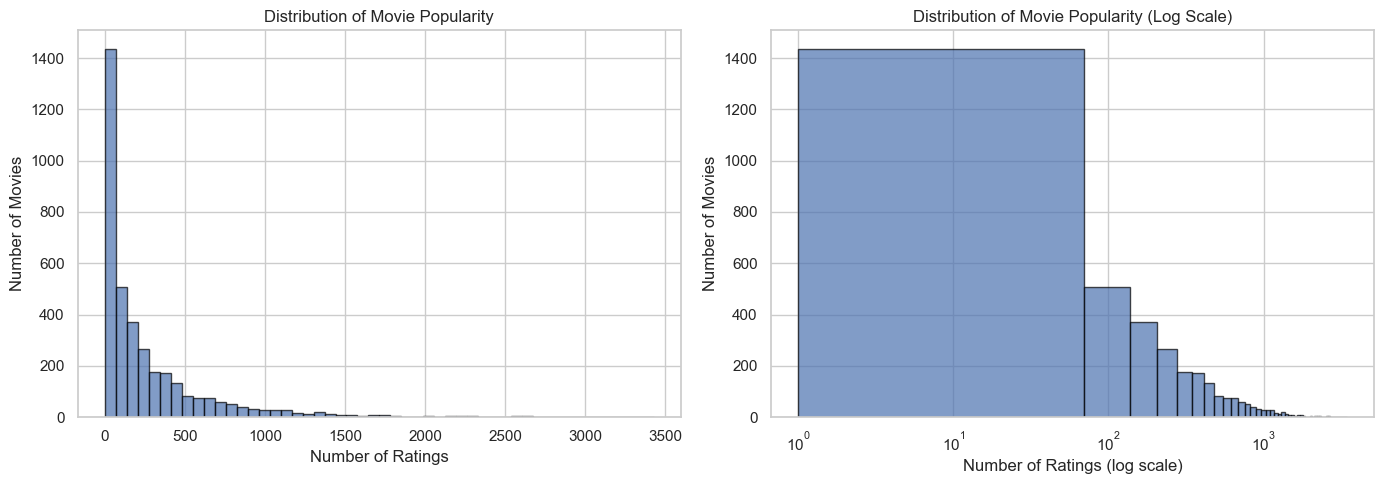

In [14]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes[0].hist(
    ratings_per_movie,
    bins=50,
    edgecolor="black",
    alpha=0.7
)
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Distribution of Movie Popularity")

axes[1].hist(
    ratings_per_movie,
    bins=50,
    edgecolor="black",
    alpha=0.7
)
axes[1].set_xlabel("Number of Ratings (log scale)")
axes[1].set_ylabel("Number of Movies")
axes[1].set_title("Distribution of Movie Popularity (Log Scale)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

In [15]:
sorted_movie_counts = ratings_per_movie.sort_values(ascending=False)
cumulative_ratings = sorted_movie_counts.cumsum()
total_ratings = cumulative_ratings.iloc[-1]

top_1_percent_movies = int(len(sorted_movie_counts) * TOP_PERCENT_TIERS[0])
top_5_percent_movies = int(len(sorted_movie_counts) * TOP_PERCENT_TIERS[1])
top_10_percent_movies = int(len(sorted_movie_counts) * TOP_PERCENT_TIERS[2])
top_20_percent_movies = int(len(sorted_movie_counts) * TOP_PERCENT_TIERS[3])

print(f"Top 1% of movies ({top_1_percent_movies} movies): {cumulative_ratings.iloc[top_1_percent_movies-1]/total_ratings:.1%} of ratings")
print(f"Top 5% of movies ({top_5_percent_movies} movies): {cumulative_ratings.iloc[top_5_percent_movies-1]/total_ratings:.1%} of ratings")
print(f"Top 10% of movies ({top_10_percent_movies} movies): {cumulative_ratings.iloc[top_10_percent_movies-1]/total_ratings:.1%} of ratings")
print(f"Top 20% of movies ({top_20_percent_movies} movies): {cumulative_ratings.iloc[top_20_percent_movies-1]/total_ratings:.1%} of ratings")

Top 1% of movies (37 movies): 8.7% of ratings
Top 5% of movies (185 movies): 28.3% of ratings
Top 10% of movies (370 movies): 44.4% of ratings
Top 20% of movies (741 movies): 65.2% of ratings


## 5. Temporal Dynamics

In [16]:
ratings["datetime"] = pandas.to_datetime(
    ratings["timestamp"],
    unit="s"
)
ratings["date"] = ratings["datetime"].dt.date
ratings["year_month"] = ratings["datetime"].dt.to_period("M")

print(f"Date range: {ratings['datetime'].min()} to {ratings['datetime'].max()}")
print(f"Duration: {(ratings['datetime'].max() - ratings['datetime'].min()).days} days")

Date range: 2000-04-25 23:05:32 to 2003-02-28 17:49:50
Duration: 1038 days


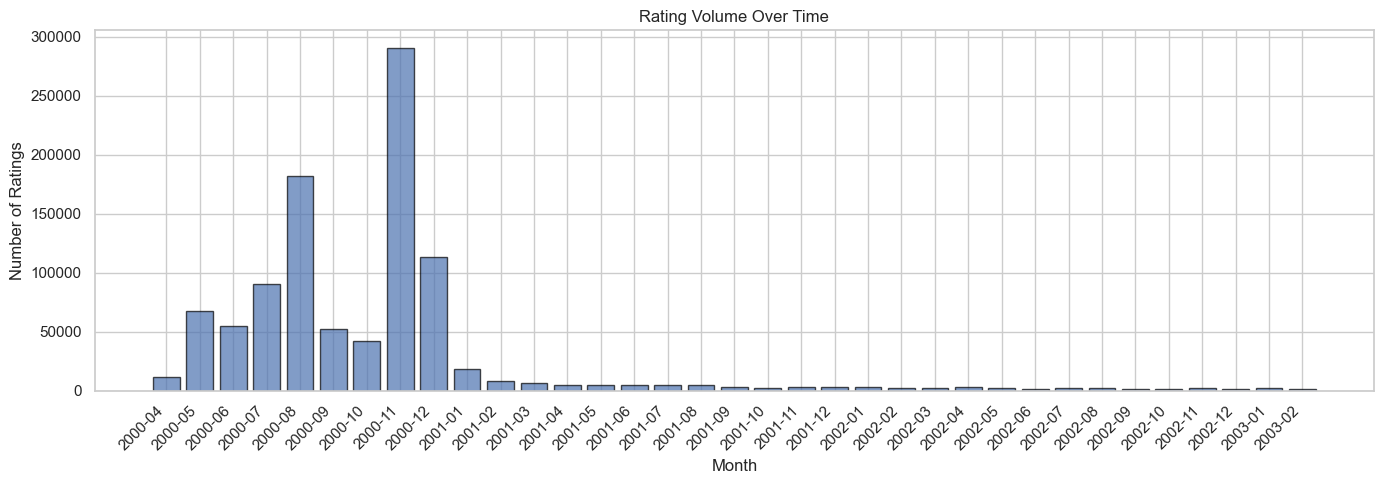

In [17]:
monthly_ratings = ratings.groupby("year_month").size()

figure, axis = plt.subplots(figsize=(14, 5))

axis.bar(
    range(len(monthly_ratings)),
    monthly_ratings.values,
    edgecolor="black",
    alpha=0.7
)
axis.set_xticks(range(len(monthly_ratings)))
axis.set_xticklabels(
    [str(period) for period in monthly_ratings.index],
    rotation=45,
    ha="right"
)
axis.set_xlabel("Month")
axis.set_ylabel("Number of Ratings")
axis.set_title("Rating Volume Over Time")

plt.tight_layout()
plt.show()

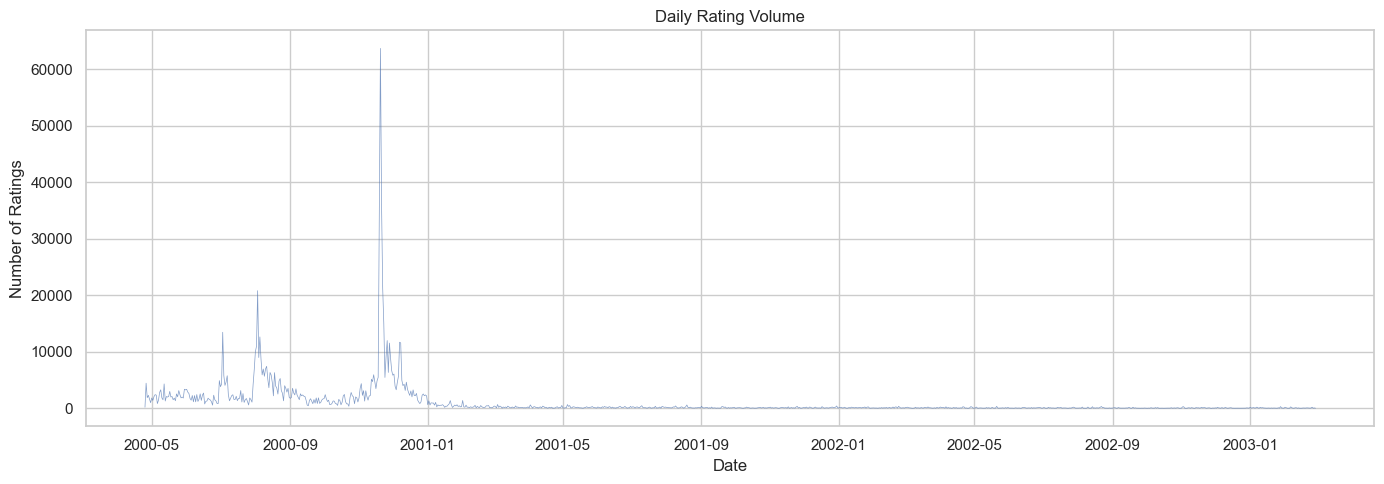

In [18]:
daily_ratings = ratings.groupby("date").size()

figure, axis = plt.subplots(figsize=(14, 5))

axis.plot(
    daily_ratings.index,
    daily_ratings.values,
    alpha=0.7,
    linewidth=0.5
)
axis.set_xlabel("Date")
axis.set_ylabel("Number of Ratings")
axis.set_title("Daily Rating Volume")

plt.tight_layout()
plt.show()

## 6. Rating Value Distribution

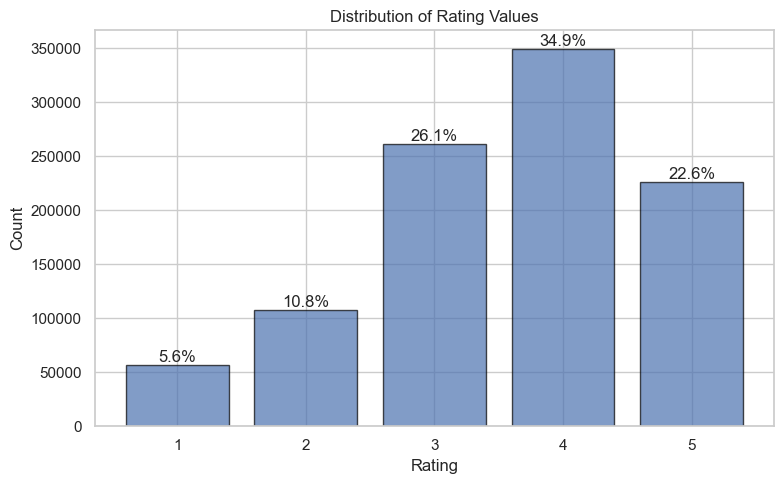

In [19]:
rating_counts = ratings["rating"].value_counts().sort_index()

figure, axis = plt.subplots(figsize=(8, 5))

axis.bar(
    rating_counts.index,
    rating_counts.values,
    edgecolor="black",
    alpha=0.7
)
axis.set_xlabel("Rating")
axis.set_ylabel("Count")
axis.set_title("Distribution of Rating Values")
axis.set_xticks([1, 2, 3, 4, 5])

for rating, count in rating_counts.items():
    axis.annotate(
        f"{count/len(ratings)*100:.1f}%",
        xy=(rating, count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [20]:
print(f"Mean rating: {ratings['rating'].mean():.2f}")
print(f"Median rating: {ratings['rating'].median():.0f}")
print(f"Standard deviation: {ratings['rating'].std():.2f}")

Mean rating: 3.58
Median rating: 4
Standard deviation: 1.12


## 7. Data Pathologies

### 7.1 Popularity Bias

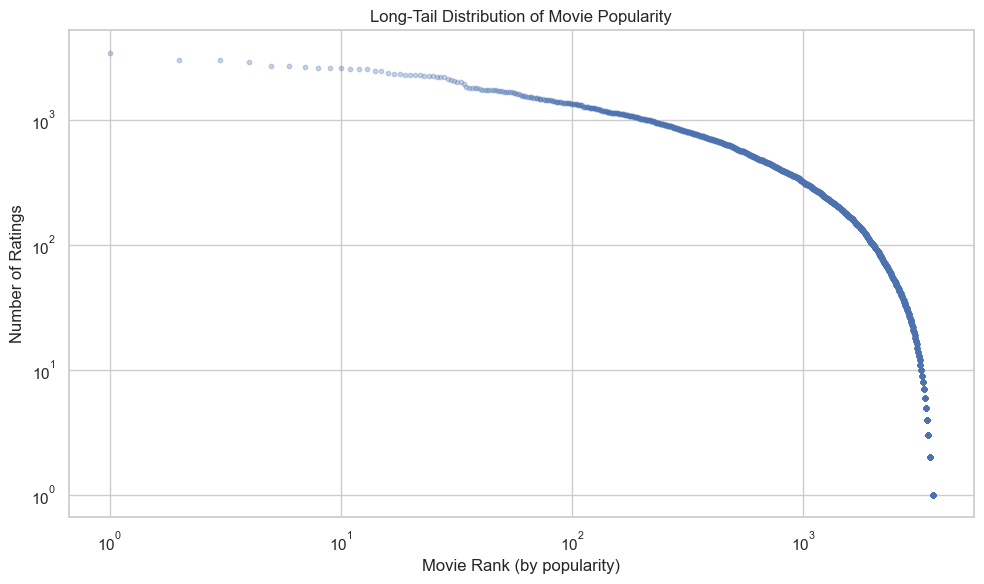

In [21]:
movie_rank = ratings_per_movie.rank(ascending=False)

figure, axis = plt.subplots(figsize=(10, 6))

axis.scatter(
    movie_rank,
    ratings_per_movie,
    alpha=0.3,
    s=10
)
axis.set_xlabel("Movie Rank (by popularity)")
axis.set_ylabel("Number of Ratings")
axis.set_title("Long-Tail Distribution of Movie Popularity")
axis.set_xscale("log")
axis.set_yscale("log")

plt.tight_layout()
plt.show()

In [22]:
def compute_gini(values):
    sorted_values = numpy.sort(values)
    length = len(sorted_values)
    cumulative = numpy.cumsum(sorted_values)
    gini = (2 * numpy.sum((numpy.arange(1, length + 1) * sorted_values))) / (length * numpy.sum(sorted_values)) - (length + 1) / length
    return gini

In [23]:
movie_gini = compute_gini(ratings_per_movie.values)
user_gini = compute_gini(ratings_per_user.values)

print(f"Gini coefficient for movie popularity: {movie_gini:.4f}")
print(f"Gini coefficient for user activity: {user_gini:.4f}")

Gini coefficient for movie popularity: 0.6336
Gini coefficient for user activity: 0.5286


### 7.2 Cold-Start Problem

In [24]:
cold_movies = (ratings_per_movie < COLD_START_THRESHOLD).sum()
cold_users = (ratings_per_user < COLD_START_THRESHOLD).sum()

print(f"Movies with fewer than {COLD_START_THRESHOLD} ratings: {cold_movies} ({cold_movies/len(ratings_per_movie)*100:.1f}%)")
print(f"Users with fewer than {COLD_START_THRESHOLD} ratings: {cold_users} ({cold_users/len(ratings_per_user)*100:.1f}%)")

Movies with fewer than 20 ratings: 663 (17.9%)
Users with fewer than 20 ratings: 0 (0.0%)


### 7.3 Positive Rating Bias

In [25]:
positive_ratings = (ratings["rating"] >= 4).sum()
negative_ratings = (ratings["rating"] <= 2).sum()
neutral_ratings = (ratings["rating"] == 3).sum()

print(f"Positive ratings (4-5): {positive_ratings} ({positive_ratings/len(ratings)*100:.1f}%)")
print(f"Neutral ratings (3): {neutral_ratings} ({neutral_ratings/len(ratings)*100:.1f}%)")
print(f"Negative ratings (1-2): {negative_ratings} ({negative_ratings/len(ratings)*100:.1f}%)")

Positive ratings (4-5): 575281 (57.5%)
Neutral ratings (3): 261197 (26.1%)
Negative ratings (1-2): 163731 (16.4%)


## 8. Summary and Modeling Implications

### Key Findings

1. **Extreme Sparsity**: The user-movie matrix is over 95% sparse, meaning most user-movie pairs have no observed rating.

2. **Popularity Bias**: Movie popularity follows a long-tail distribution with a small percentage of movies receiving the majority of ratings. This creates challenges for recommending less popular (but potentially relevant) movies.

3. **User Activity Skew**: While MovieLens requires minimum 20 ratings per user, activity varies significantly. Power users may disproportionately influence collaborative signals.

4. **Positive Rating Bias**: Users predominantly rate movies positively, with ratings skewed toward 4-5 stars.

5. **Temporal Patterns**: Rating activity varies over time, with potential seasonality and trend effects.

### Modeling Implications

| Finding | Implication | Recommendation |
|---------|-------------|----------------|
| High sparsity | Collaborative filtering needs strong regularization | Use matrix factorization with regularization; consider hybrid approaches |
| Popularity bias | Models may over-recommend popular movies | Evaluate with beyond-accuracy metrics (coverage, novelty); consider popularity debiasing |
| Positive rating bias | Rating prediction may be easier but less informative | Consider ranking-based evaluation over rating prediction |
| Temporal dynamics | User preferences may evolve | Use temporal splits for evaluation; consider time-aware models |
| Cold-start movies | New movies lack collaborative signals | Content-based filtering can address cold-start; hybrid models recommended |

### Evaluation Strategy Implications

- **Use temporal splits** to simulate real deployment scenarios
- **Primary metric: NDCG@10** for ranking quality (more practical than rating prediction)
- **Include beyond-accuracy metrics** (coverage, novelty, diversity) to detect popularity bias in recommendations
- **Stratify analysis** by user activity level and movie popularity to understand model behavior across segments